In [19]:
# USUAL IMPORTS
import numpy as np
import matplotlib.pyplot as plt

# IMPORT FROM OUR MODULE
import helpers as hp

# SETTING SEED FOR REPRODUCIBILITY
np.random.seed(0)

# Parameters
Ntsteps = 5000

Ref. "A Statistical Framework for Neuroimaging data Analysis Based on Mutual Information Estimated via a Gaussian Copula"

# **WHAT CAN MI ESTIMATE**
- MI between neural variable and an external signal
- MI between two neural variables
- Transfer entropy/Granger causality :: CMI between two neural variables

_NOTICE:_ The key idea is that MI should detect **any statistical dependence**. The main issue is how to estimate MI though. 

# **SIMULATED DATA**
1) Simulate an external signal $S(t)$ and a neural variable $X(t)$ with three different types of relation with or without lag. 

    Types: 
    - linear
    - monotonic non linear
    - non monotonic (quadratic for example)
 
2) Compute MI (with or without lag, and maybe conditioning on $X(t-1)$) with different methods. 
    
    Methods: 
    - Gaussian (assuming joint normality)
    - Binning 
    - KDE ** maybe ** 
    - Gaussian copula 

## GENERATING SYNTHETIC NEURAL DATA

Let's start simple! We generate an external signal $S(t) \sim \mathcal{N}(0,1)$. On that we generate the neural variable: $X(t) = f(S(t)) + \eta(t)$, with $\eta(t) \sim \mathcal{N}(0,\sigma^2)$ being the additional noise.  

In [20]:
# External signal (stimulus)
S = np.random.normal(0, 1, Ntsteps) # You can try change mu see how quad joint distribution changes!
# hp.plot_ts_and_hist(S, "external signal S(t)", color = "steelblue")

#### Linear relationship
$$
X(t) = S(t) + \eta(t)
$$

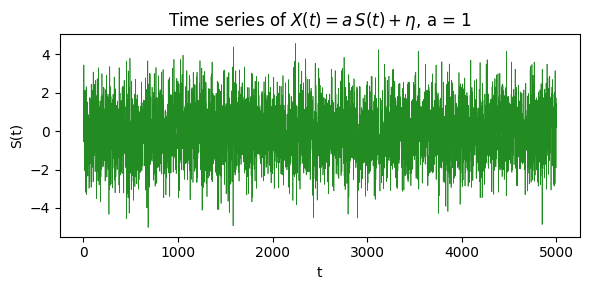

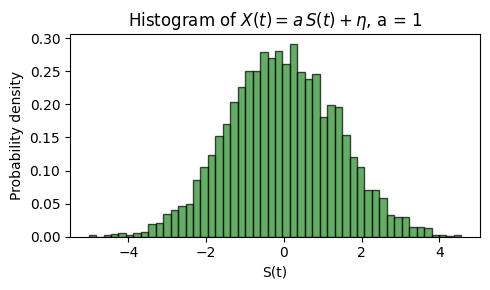

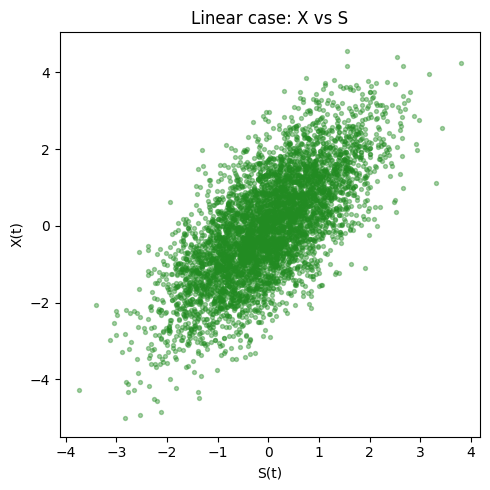

In [21]:
# ------ Linear, no AR, no LAG ------------
X_linear = hp.generate_neural_variable(S, noise_std = 1) # --> we can change also the noise strength from here directly! (Default is 1)
# ------ Linear, no AR, LAG of 2 ---------------
# X_linear = hp.generate_neural_variable(S, lag = True, tau = 2)
# ------ Linear, AR, no LAG ---------------
# X_linear = hp.generate_neural_variable(S, auto_regr=True)

hp.plot_ts_and_hist(X_linear, r"$X(t) = a\,S(t) + \eta$, a = 1", color = "forestgreen")

hp.plot_joint_distribution(S, X_linear, 
                           title_string="Linear case: X vs S",
                           color="forestgreen") #, density = True)

#### Monotonic nonlinear
$$
X(t) = S(t)^3 + \eta(t)
$$

OR 

$$
X(t) = \tanh(S(t)) + \eta(t)
$$

_NOTICE_: tanh is nice because it is smooth and monotonically increasing as the cubic, but it is also saturating (thus "neuron-like" and not exploding numerically). 

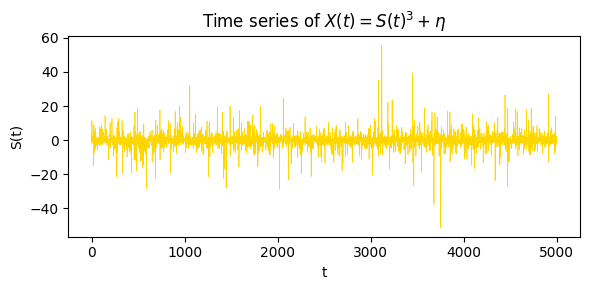

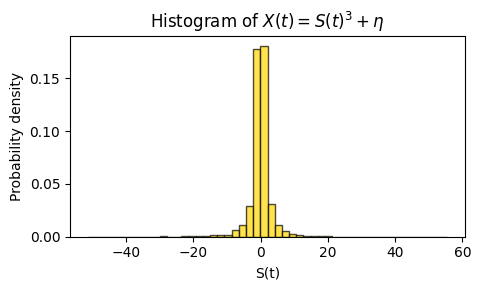

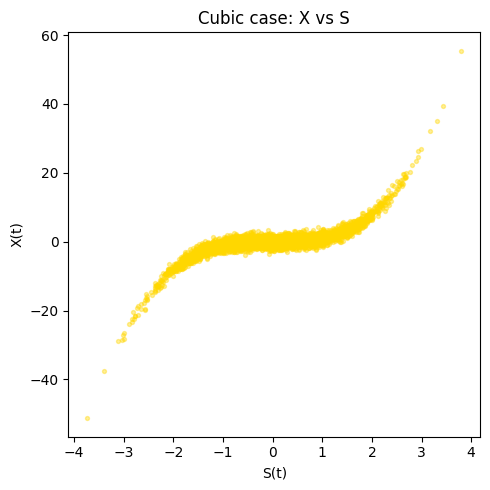

In [22]:
# ------ Cubic, no AR, no LAG ------------
X_cub = hp.generate_neural_variable(S, relation="cubic")
hp.plot_ts_and_hist(X_cub, r"$X(t) = S(t)^3 + \eta$", color = "gold")
hp.plot_joint_distribution(S, X_cub,
                           title_string="Cubic case: X vs S",
                           color="gold")

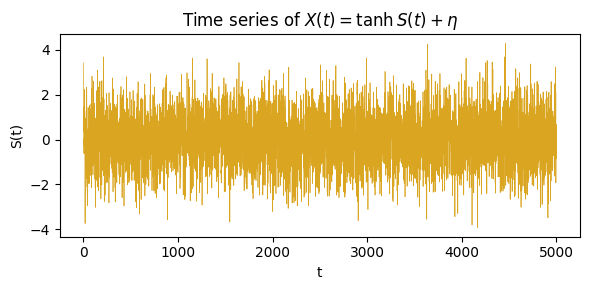

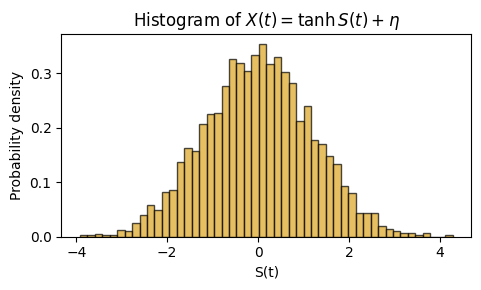

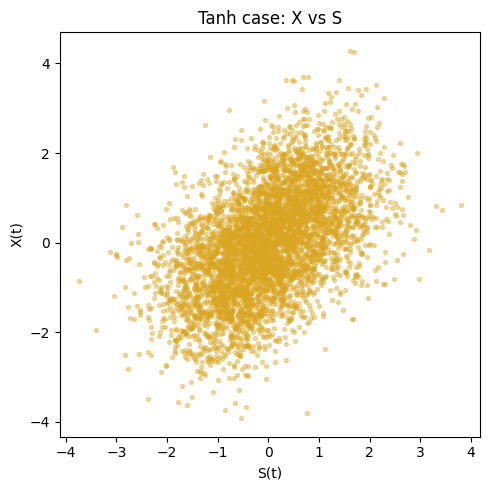

In [23]:
# ------ Tanh, no AR, no LAG ------------
X_tanh = hp.generate_neural_variable(S, relation="tanh")
hp.plot_ts_and_hist(X_tanh, r"$X(t) = \tanh{S(t)} + \eta$", color = "goldenrod")
hp.plot_joint_distribution(S, X_tanh,
                           title_string="Tanh case: X vs S",
                           color="goldenrod")

### Non-monotonic 
$$
X(t) = S(t)^2 + \eta(t)
$$

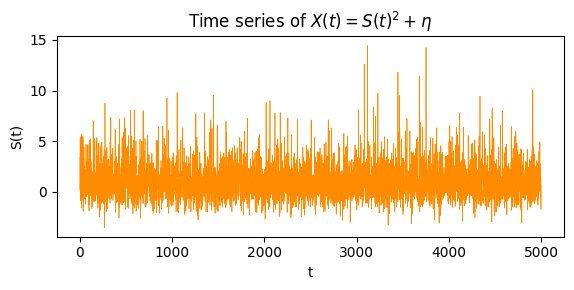

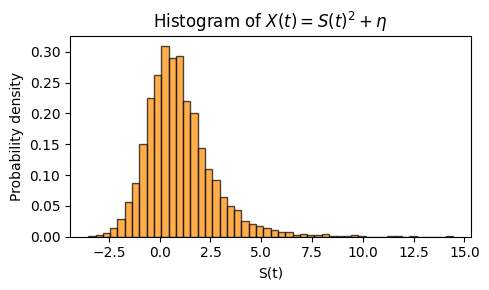

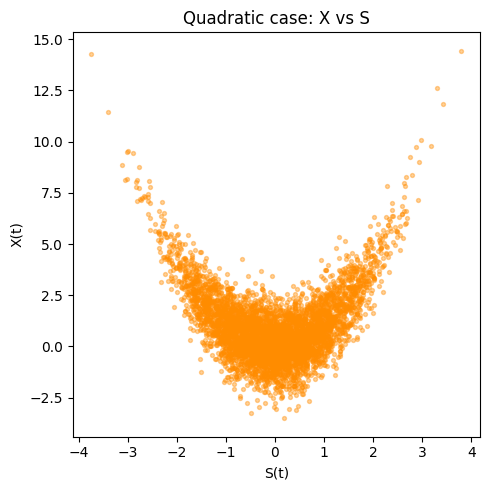

In [24]:
X_quad = hp.generate_neural_variable(S, relation= "quadratic")
hp.plot_ts_and_hist(X_quad, r"$X(t) = S(t)^2 + \eta$", color = "darkorange")
hp.plot_joint_distribution(S, X_quad,
                           title_string="Quadratic case: X vs S",
                           color="darkorange")

## M.I. ASSUMING JOINT NORMALITY
If $X$ and $S$ are jointly Gaussian, the mutual information is: 
$$
I(X; S) = - \frac{1}{2}\log_2(1 - \rho^2)
$$
where: 
$$
\rho = corr(X,S) \text{\ \ is the Pearson correlation coefficient}. 
$$

_NOTICE:_ 
A pair (U,V) is jointly Gaussian if EVERY LINEAR COMBINATION of aU+bV is Gaussian ($\forall a, b \in \mathbb{R}$). Thus, having U and V Gaussian is not sufficient (although necessary): you need independence OR a known linear relationship to guarantee joint Gaussianity. 

This is why in our linear case MI is correct, while in the other cases it may be non-zero but not-exact or even not capture any correlation at all, even though correlations are present. 

In [25]:
# Example: 
mi_linear = hp.gaussian_mi(X_linear, S)
print(f"MI (linear) = {mi_linear:.3f} bits")

mi_cub = hp.gaussian_mi(X_cub, S)
print(f"MI (cubic) ≈ {mi_cub:.3f} bits (Gaussian approx)")

mi_tanh = hp.gaussian_mi(X_tanh, S)
print(f"MI (tanh) ≈ {mi_tanh:.3f} bits (Gaussian approx)")

mi_quad = hp.gaussian_mi(X_quad, S)
print(f"MI (quad) ≈ {mi_quad:.3f} bits (Gaussian approx)")

MI (linear) = 0.498 bits
MI (cubic) ≈ 0.598 bits (Gaussian approx)
MI (tanh) ≈ 0.226 bits (Gaussian approx)
MI (quad) ≈ 0.000 bits (Gaussian approx)


**NOTICE:**
Variations (maybe in some sistematic way) can be tried and commented (as for considering AR or lag presence cases). 

# **TO THINK AND MAYBE GO ON FROM HERE** ... do we have a way to compute the exact (analytical) MI to compare with Gaussian MI here?

# **REAL DATA**